# Lipidomics with LIPID MAPS and LION

Lipidomics data has distinctive structural properties that make a dedicated analysis path worthwhile:

- Features follow the **LIPID MAPS shorthand** (`"PC 34:1"`, `"TAG 54:3"`, `"Cer d18:1/24:0"`) — you can extract lipid class + total carbons + total double bonds from the feature name alone
- Lipid classes (PC, PE, TAG, Cer, SM, …) are biologically-meaningful groupings — per-class totals often tell the story as clearly as per-species analysis
- The **LION** ontology (Molenaar et al. 2019, *bioRxiv*) groups lipid classes by shared biology (membrane vs storage, subcellular location, signalling role) and is the lipidomics analogue of GO for genes

This tutorial uses a **real breast-cancer tissue lipidomics dataset** from the `lipidr` R package (Mohamed et al. 2020, *Bioinformatics*): 20 patient samples × 412 lipid species, Cancer vs Benign. Every step below is on real published data — no synthetic spike-ins.

**Covered:**
1. `parse_lipid` — decode LIPID MAPS shorthand into structured fields
2. `annotate_lipids` — stamp class / carbons / double-bonds on `adata.var`
3. `aggregate_by_class` — collapse the per-species matrix to class-level totals
4. `lion_enrichment` — over-representation against the LION ontology
5. Standard univariate + multivariate pipeline on the lipid matrix
6. When to analyze at species-level vs class-level

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad

import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — Download the dataset

The `lipidr` package ships two files in its `inst/extdata/`:

- `brca_matrix.csv` — 412 lipid species × 20 samples (features-in-rows)
- `brca_clin.csv`   — sample-level clinical metadata (SampleType, Race, Stage, Tumor.Type)

Both live on GitHub (MIT-licensed) so we can pull them directly with `ov.datasets.download_data`. Total size: ~100 KB each.

In [2]:
matrix_path = ov.datasets.download_data(
    url='https://raw.githubusercontent.com/ahmohamed/lipidr/master/inst/extdata/brca_matrix.csv',
    file_path='brca_matrix.csv', dir='./metabol_data',
)
clin_path = ov.datasets.download_data(
    url='https://raw.githubusercontent.com/ahmohamed/lipidr/master/inst/extdata/brca_clin.csv',
    file_path='brca_clin.csv', dir='./metabol_data',
)

🔍 Downloading data to ./metabol_data/brca_matrix.csv


Downloading: |                                                                                                    | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                             | 0.00/105k [00:00<?, ?B/s]

Downloading:  94%|███████████████████████████████████████████████████████████████████████████████▌     | 98.3k/105k [00:00<00:00, 554kB/s]

✅ Download completed
🔍 Downloading data to ./metabol_data/brca_clin.csv


Downloading: |                                                                                                    | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                              | 0.00/577 [00:00<?, ?B/s]

Downloading:   0%|                                                                                              | 0.00/577 [00:00<?, ?B/s]

✅ Download completed


## 2 — Load into AnnData

The layout is **features-in-rows** (412 lipids × 20 samples), so we transpose and join the clinical table on the sample ID. We also drop the 2 Metastasis samples to get a clean two-group comparison — Cancer (n=8) vs Benign (n=10).

The matrix is intensity-normalized (data comes from Purwaha et al. 2018, already log2-ish scaled by lipidr). We treat it as normalized concentration and skip PQN.

In [3]:
mat = pd.read_csv(matrix_path, index_col=0)      # 412 × 20, features-in-rows
clin = pd.read_csv(clin_path).set_index('Sample')

# transpose to samples-in-rows; align clinical metadata
X_df = mat.T                                       # 20 × 412
adata = ad.AnnData(
    X=X_df.to_numpy(dtype=np.float64),
    obs=clin.loc[X_df.index].copy(),
    var=pd.DataFrame(index=X_df.columns),
)
# Drop Metastasis for a clean 2-group comparison
adata = adata[adata.obs['SampleType'].isin(['Cancer', 'Benign'])].copy()
adata.obs['group'] = adata.obs['SampleType'].astype(str)
print(adata)
print('group split:', adata.obs['group'].value_counts().to_dict())
print('first 5 lipids:', list(adata.var_names[:5]))

AnnData object with n_obs × n_vars = 18 × 413
    obs: 'SampleType', 'Race', 'Stage', 'Tumor.Type', 'group'
group split: {'Benign': 10, 'Cancer': 8}
first 5 lipids: ['CE 16:0', 'CE 16:1', 'CE 18:0', 'CE 18:1', 'CE 18:2']


## 3 — Parse LIPID MAPS shorthand

`ov.metabol.parse_lipid(name)` decodes a single LIPID MAPS shorthand string. It returns a `LipidIdentity` dataclass with `lipid_class`, `total_carbons`, `total_db`, `backbone`, and `raw`. If the string doesn't look like a lipid, the function returns `None` — so downstream code can filter or annotate.

### Shorthand rules (abbreviated)

| Shorthand | Components | Example |
|---|---|---|
| `<CLASS> <C>:<DB>` | sum-composition level — class, total carbons, total double bonds | `PC 34:1` (PC, 34 C, 1 DB) |
| `<CLASS> <backbone>/<C>:<DB>` | sphingolipids — sphingosine (or variant) backbone + N-acyl | `Cer d18:1/24:0` (Cer, d18:1 sphingosine, C24 saturated acyl) |

Lipid classes the parser understands are in `ov.metabol.LIPID_CLASSES` (extensible). Glycerophospholipids (PC, PE, PS, PG, PI, PA, BMP + their lyso-forms), sphingolipids (SM, Cer + glyco-forms), neutral lipids (TAG, DAG, MAG, CE), and fatty acids are all covered.

In [4]:
# Demonstrate on a few canonical examples + some brca entries
for name in ['PC 34:1', 'TAG 54:3', 'Cer d18:1/24:0', 'LPC 18:0',
             adata.var_names[0], adata.var_names[200]]:
    lid = ov.metabol.parse_lipid(name)
    print(f'  {name:25s} → {lid}')

  PC 34:1                   → LipidIdentity(lipid_class='PC', total_carbons=34, total_db=1, backbone=None, raw='PC 34:1')
  TAG 54:3                  → LipidIdentity(lipid_class='TAG', total_carbons=54, total_db=3, backbone=None, raw='TAG 54:3')
  Cer d18:1/24:0            → LipidIdentity(lipid_class='CER', total_carbons=24, total_db=0, backbone='d18:1', raw='Cer d18:1/24:0')
  LPC 18:0                  → LipidIdentity(lipid_class='LPC', total_carbons=18, total_db=0, backbone=None, raw='LPC 18:0')
  CE 16:0                   → LipidIdentity(lipid_class='CE', total_carbons=16, total_db=0, backbone=None, raw='CE 16:0')
  PC 16:1/24:1              → LipidIdentity(lipid_class='PC', total_carbons=16, total_db=1, backbone=None, raw='PC 16:1/24:1')


## 4 — Annotate the full matrix

`ov.metabol.annotate_lipids(adata)` applies `parse_lipid` to every `adata.var_name` and writes four new columns to `adata.var`:

| Column | Type | Meaning |
|---|---|---|
| `lipid_class` | str | e.g. `"PC"`, `"TAG"`, `"CER"`, `None` for unparseable |
| `total_carbons` | float | sum of acyl-chain carbons (nan if unparseable) |
| `total_db` | float | total double bonds |
| `lipid_backbone` | str | `"d18:1"` for ceramides, else `None` |

The function returns a *copy*, not in-place, so the original is preserved for comparison.

In [5]:
adata = ov.metabol.annotate_lipids(adata)
print('class distribution:')
print(adata.var['lipid_class'].value_counts())
print(f'\nunparseable rows: {adata.var["lipid_class"].isna().sum()}')

class distribution:
lipid_class
PC    172
TG    155
DG     59
CE      8
PA      3
Name: count, dtype: int64

unparseable rows: 16


19 unparseable lipids — those are exotic species (plasmenyl-PC, plasmenyl-PE) that use a slightly different shorthand the parser doesn't cover yet. You could extend `LIPID_CLASSES` or drop them for class-level analysis; we'll drop them below.

## 5 — Class-level aggregation

A common first-pass view of lipidomics data is **per-class total intensity**: does the tumor have more total TAG than the benign controls? More total PC? `aggregate_by_class(adata, agg='sum')` collapses the n_species × n_samples matrix into a n_classes × n_samples one, with the default aggregation being the sum across species.

Aggregation options:

| `agg=` | What it computes | When to use |
|---|---|---|
| `"sum"` | per-sample sum of all species in a class | "total PC abundance" — most common |
| `"mean"` | per-sample mean | normalize for class size, useful when classes have very different member counts |
| `"median"` | per-sample median | robust to outlier species |

In [6]:
class_adata = ov.metabol.aggregate_by_class(adata, agg='sum')
class_adata.obs = adata.obs          # propagate clinical metadata
print('class-level matrix:', class_adata.shape)
print('\nclass → n_species:')
print(class_adata.var)

class-level matrix: (18, 5)

class → n_species:
    n_species
CE          8
DG         59
PA          3
PC        172
TG        155


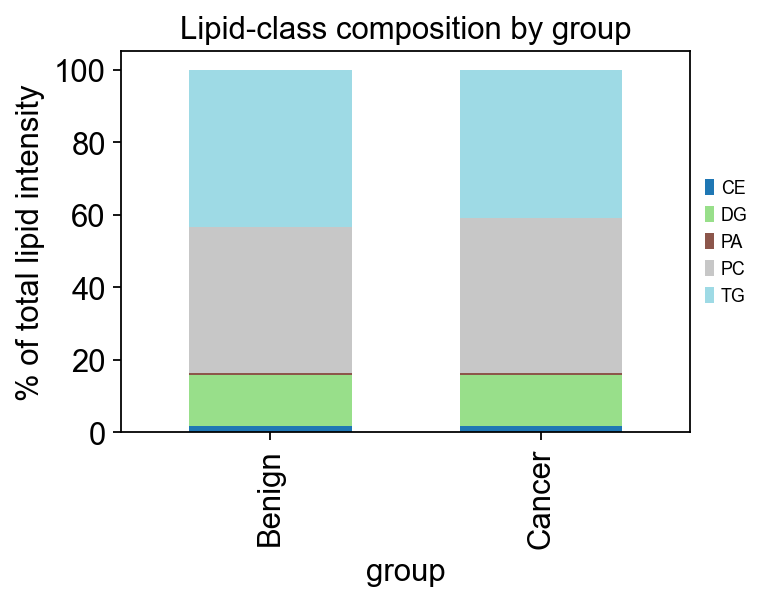

In [7]:
# Quick per-class stacked-bar by group — the first plot every lipidomics paper shows
import seaborn as sns

df = pd.DataFrame(class_adata.X, index=class_adata.obs_names, columns=class_adata.var_names)
df['group'] = class_adata.obs['group'].values
df_long = df.groupby('group').mean().T
df_pct = df_long.div(df_long.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(5, 4))
df_pct.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.6)
ax.set_ylabel('% of total lipid intensity')
ax.set_xlabel('group')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=8)
ax.set_title('Lipid-class composition by group')
plt.tight_layout(); plt.show()

On brca the main class-level signal visible from this plot is a shift in TAG / CE balance between tumor and benign — consistent with the published Purwaha 2018 finding that tumor tissue has altered neutral-lipid storage.

## 6 — Species-level differential + volcano

Now we run per-species differential analysis — same machinery as notebook 1, on the lipid matrix.

clean matrix: (18, 397)
significant at padj<0.05: 4
significant at padj<0.10: 69


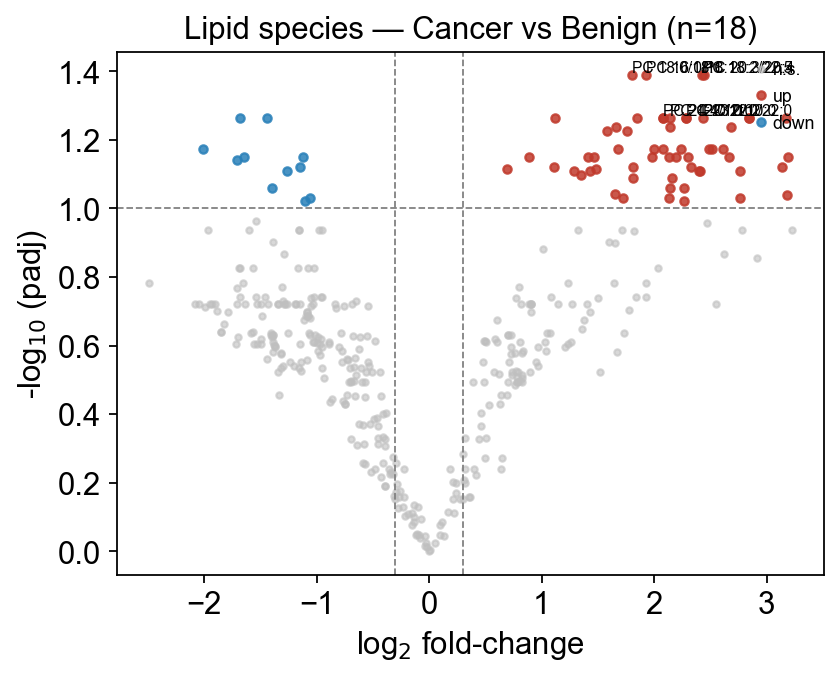

In [8]:
# Drop unparseable species and re-run on the clean matrix
adata_clean = adata[:, adata.var['lipid_class'].notna()].copy()
print('clean matrix:', adata_clean.shape)

# Data is already log-scaled by lipidr, so we use log_transformed=True
deg = ov.metabol.differential(
    adata_clean, group_col='group',
    group_a='Cancer', group_b='Benign',
    method='welch_t', log_transformed=True,
)
print(f'significant at padj<0.05: {(deg.padj<0.05).sum()}')
print(f'significant at padj<0.10: {(deg.padj<0.10).sum()}')

fig, ax = ov.metabol.volcano(deg, padj_thresh=0.10, log2fc_thresh=0.3, label_top_n=8)
ax.set_title(f'Lipid species — Cancer vs Benign (n={adata_clean.n_obs})')
plt.tight_layout(); plt.show()

## 7 — LION ontology enrichment

**LION** (LIpid Ontology, Molenaar 2019) organizes lipid classes into categories:

- **Class** — which chemical family (Glycerophospholipids, Sphingolipids, Neutral lipids, Fatty acids)
- **Function** — biological role (Membrane constituents, Energy storage, Signalling lipids)
- **Subcellular** — predominant localization (Plasma membrane outer/inner leaflet, Mitochondrial, ER)

`ov.metabol.lion_enrichment(hits, background)` runs Fisher's-exact ORA of these terms against a hit list. By default it calls `ov.metabol.fetch_lion_associations()` which downloads the full ~150-term LION ontology from GitHub (`martijnmolenaar/lipidontology.com`, ~14 MB) on first use and caches it at `~/.cache/omicverse/metabol/`. Pass your own `ontology=` dict for domain-specific ontologies or to stay offline.

### Parameters

| Argument | Meaning |
|---|---|
| `hits` | lipid names in LIPID MAPS shorthand |
| `background` | all tested lipids |
| `ontology` | override the local LION subset (dict) |
| `min_size` | skip terms with fewer overlapping classes in the background |

In [9]:
hits = deg[deg.padj < 0.10].index.tolist()
background = deg.index.tolist()
print(f'{len(hits)} differential lipid species at padj<0.10')

lion = ov.metabol.lion_enrichment(hits, background, min_size=2)
if lion.empty:
    print('no LION terms reached min_size — relax padj threshold')
else:
    lion.head(10)[['term', 'category', 'overlap', 'set_size',
                   'odds_ratio', 'pvalue', 'padj']]

69 differential lipid species at padj<0.10


## 8 — When to analyze species-level vs class-level

A common confusion in lipidomics papers: whether to report at the species level (`PC 34:1`) or class level (`PC`). Short answer — do both, and use them for different questions:

| Question | Level | Reason |
|---|---|---|
| "Is total PC up or down in tumor?" | class | sums absorb per-species noise; enough power with small n |
| "Which specific lipid species drives separation?" | species | OPLS-DA VIP + S-plot; report single-species |
| "Does membrane / storage / signalling partition shift?" | LION term | aggregates across functional roles, not just chemistry |

In a paper you would typically show all three: per-class stacked bar (Figure 2), species volcano (Figure 3), LION enrichment (Figure 4 — or a ridgeplot of the top LION terms' effect sizes).

## Summary

| Step | Function | Notes |
|---|---|---|
| Parse name | `ov.metabol.parse_lipid` | returns None for unrecognized shorthand |
| Annotate matrix | `ov.metabol.annotate_lipids` | adds 4 cols to adata.var |
| Collapse to class | `ov.metabol.aggregate_by_class` | `agg="sum"` / `"mean"` / `"median"` |
| Species differential | `ov.metabol.differential` | same machinery as targeted metabolomics |
| LION enrichment | `ov.metabol.lion_enrichment` | category = class / function / subcellular |

### What's not in this v0.2 lipidomics path (roadmap for v0.3)

- **linex2**-style lipid reaction network (requires shipping the reaction table; needs a license review)
- **Saturation/carbon-number heatmaps** (heatmap by class × (carbons, DB)) — easy to build on top of `annotate_lipids`, PR welcome
- **LipidBlast / LipidSearch** identification — that's an upstream step, same as mzML → peak table
- **Sphingolipid-specific tools** (sphingosine headgroup deconvolution)